In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib
from scipy import stats

In [2]:
matplotlib.rc("font", family="Microsoft JhengHei")  # Windows 範例
matplotlib.rc("axes", unicode_minus=False)

In [3]:
df= pd.read_csv("../data/data_clean.csv",index_col=0)

In [5]:
# 更精確的相對保值率
df['expected_price'] = (
    df.groupby(['reference number', 'age'])['price']
      .transform('mean')
)

df['retention_ratio'] = df['price'] / df['expected_price']

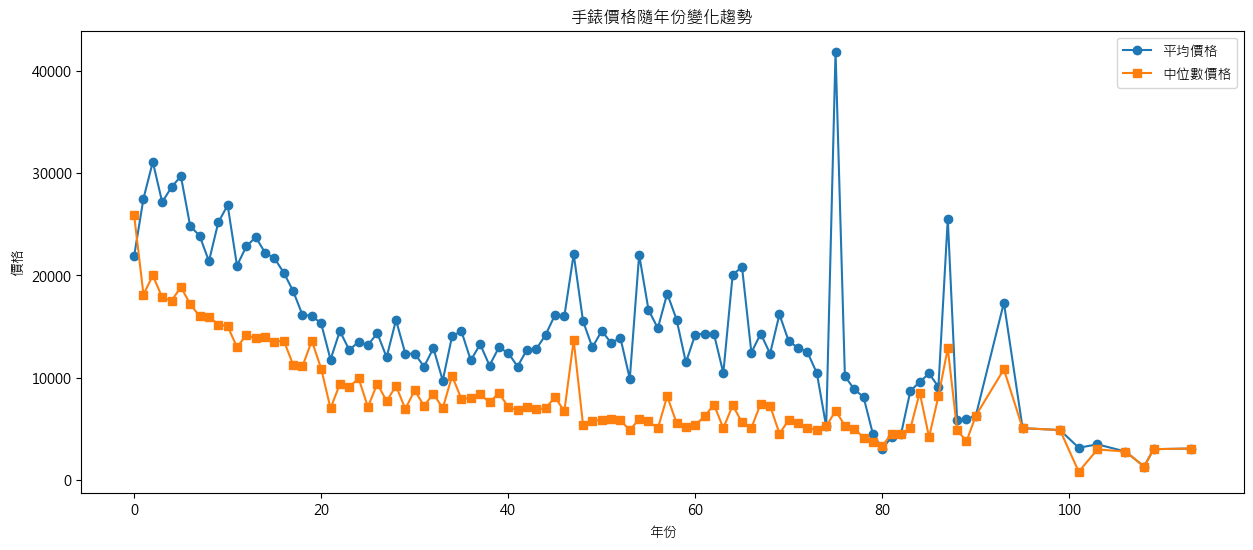

In [6]:
age_price = df.groupby('age')['price'].agg(['mean', 'median', 'std']).reset_index()
plt.figure(figsize=(15, 6))
plt.plot(age_price['age'], age_price['mean'], marker='o', label='平均價格')
plt.plot(age_price['age'], age_price['median'], marker='s', label='中位數價格')
plt.xlabel('年份')
plt.ylabel('價格')
plt.title('手錶價格隨年份變化趨勢')
plt.legend()
plt.show()

In [7]:
# 計算各品牌的價格-年份斜率（衰減速度）
brand_depreciation = {}

for brand in df['model'].unique():
    brand_data = df[df['model'] == brand]
    slope, intercept, r_value, p_value, std_err = stats.linregress(brand_data['age'], brand_data['price'])
    brand_depreciation[brand] = {
        'slope': slope,  # 負值表示衰減程度
        'r_squared': r_value**2,
        'avg_price': brand_data['price'].mean()
    }

depreciation_df = pd.DataFrame(brand_depreciation).T
depreciation_df['年衰減率'] = -depreciation_df['slope']  # 轉為正值，越小越保值
depreciation_df = depreciation_df.sort_values('年衰減率', ascending=False)
depreciation_df

,slope,r_squared,avg_price,年衰減率
Rolex Pearlmaster,-3306.898899,0.418141,77995.537037,3306.898899
Rolex Submariner,-2002.352008,0.320928,76740.000000,2002.352008
Rolex Day-Date,-1275.166843,0.088672,78763.927536,1275.166843
Rolex Yacht-Master,-1230.075146,0.184534,12162.157270,1230.075146
Rolex Day-Date 40,-875.937571,0.002152,65471.739175,875.937571
Rolex Chronograph,-864.853315,0.216885,44715.339623,864.853315
Rolex Day-Date 36,-849.186415,0.474841,32408.065331,849.186415
Rolex Yacht-Master 42,-596.220665,0.000285,42497.638095,596.220665
Rolex GMT-Master II,-458.593378,0.025844,27740.185457,458.593378
Rolex Cellini Time,-361.793186,0.325190,15474.540000,361.793186


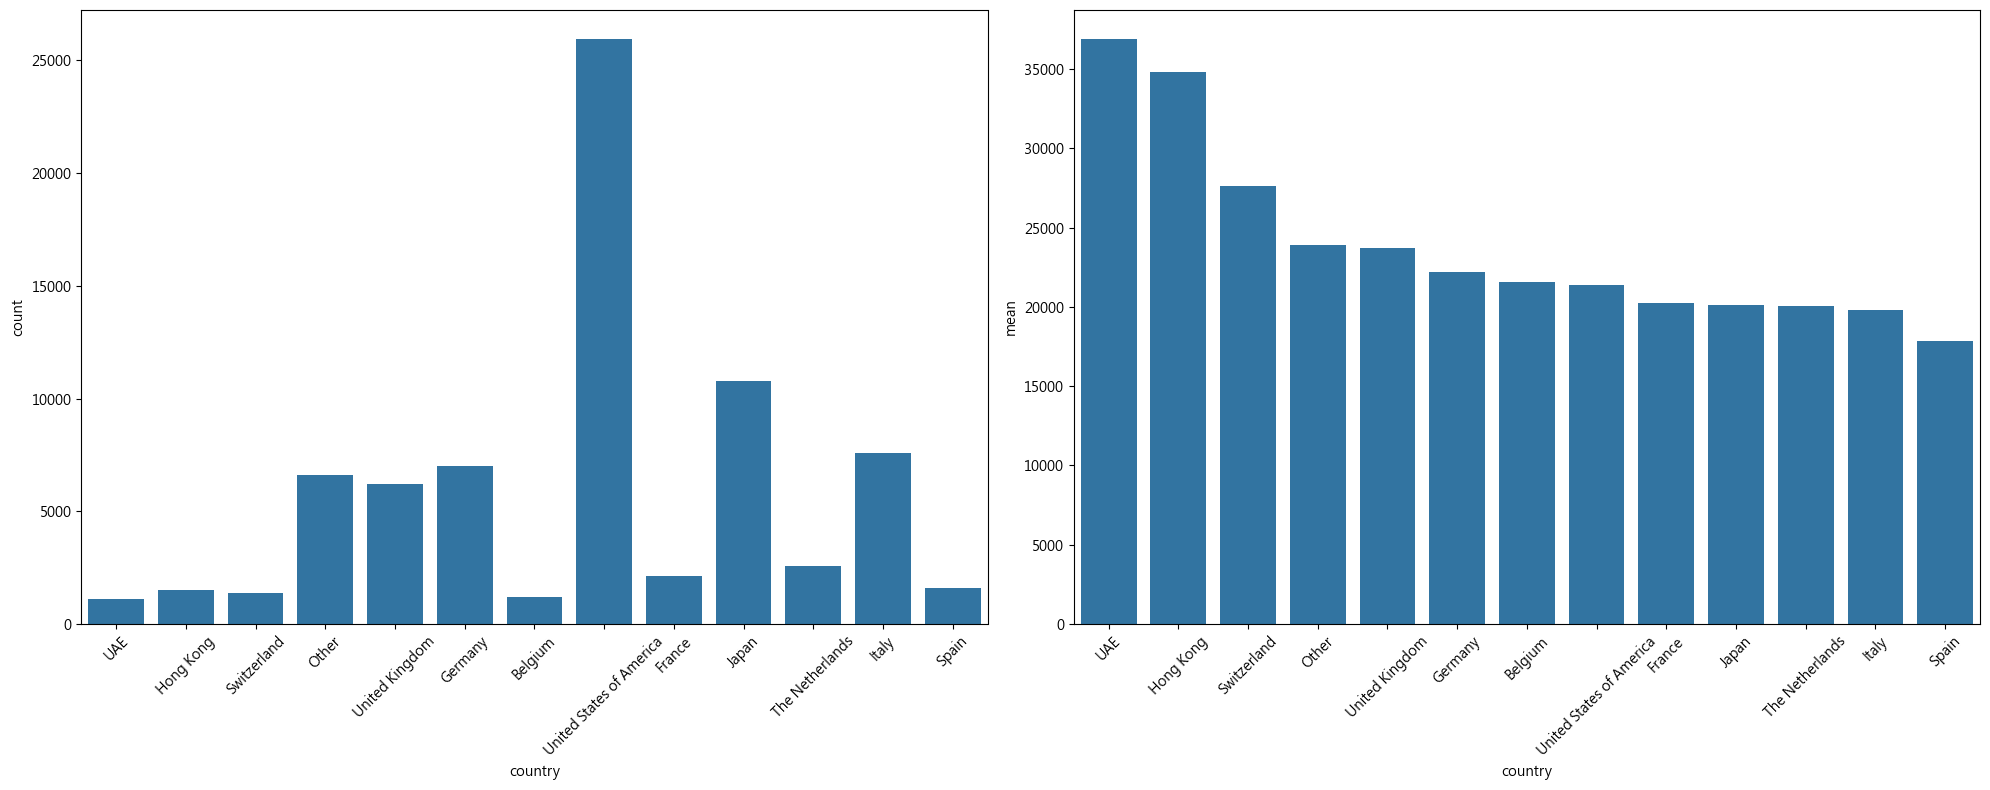

In [10]:
country_analysis = df.groupby('country')['price'].agg(['mean', 'median', 'count']).reset_index()
country_analysis = country_analysis[country_analysis['count'] >= 10]  # 過濾樣本數太少的地區
country_analysis = country_analysis.sort_values('mean', ascending=False)

fig, axes= plt.subplots(1,2,figsize=(20,8))
sns.barplot(data=country_analysis,x='country', y= 'count',ax=axes[0])
sns.barplot(x= country_analysis['country'], y= country_analysis['mean'],ax=axes[1])
axes[0].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()

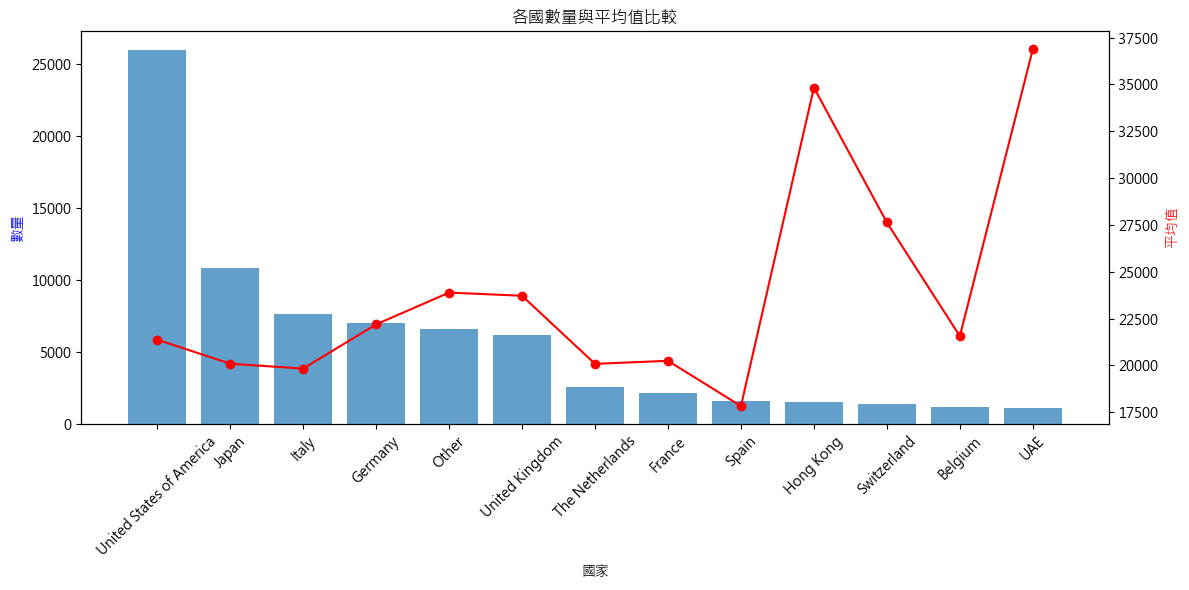

In [13]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# 排序
country_analysis_sorted = country_analysis.sort_values('count', ascending=False)

# 第一個Y軸:count
ax1.bar(country_analysis_sorted['country'], 
        country_analysis_sorted['count'], 
        alpha=0.7, label='數量')
ax1.set_xlabel('國家')
ax1.set_ylabel('數量', color='blue')
ax1.tick_params(axis='x', rotation=45)

# 第二個Y軸:mean
ax2 = ax1.twinx()
ax2.plot(country_analysis_sorted['country'], 
         country_analysis_sorted['mean'], 
         color='red', marker='o', label='平均值')
ax2.set_ylabel('平均值', color='red')

plt.title('各國數量與平均值比較')
plt.tight_layout()
plt.show()

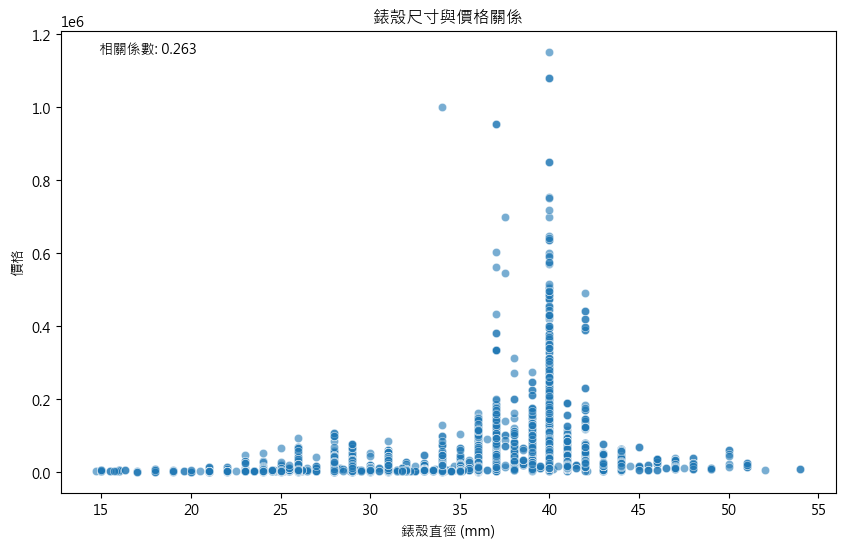

In [9]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x= df['case diameter'], y= df['price'], alpha=0.6)
plt.xlabel('錶殼直徑 (mm)')
plt.ylabel('價格')
plt.title('錶殼尺寸與價格關係')

# 計算相關係數
size_price_corr = df['case diameter'].corr(df['price'])
plt.text(0.05, 0.95, f'相關係數: {size_price_corr:.3f}', transform=plt.gca().transAxes)
plt.show()